<a id="top"></a>

# Capstone Project: Loan Default Prediction 🏦
## MIT Applied AI & Data Science Program — Capstone Project (Classification)
#### Final Submission Notebook — Business-Facing  |  Total Marks: 40

### Business Context
A major portion of retail bank profit comes from interest on home equity loans. Banks face significant financial risk from loan defaulters — bad loans (Non-Performing Assets / NPA) erode profitability and require expensive write-offs. The traditional manual credit approval process is effort-intensive, slow, and prone to human bias and error.

This project builds a machine learning classification model to predict which loan applicants are likely to default, enabling the bank to make data-driven, bias-free, and interpretable credit decisions that comply with the **Equal Credit Opportunity Act**.

### Problem Statement
Build a classification model to predict clients likely to default on their home equity loan and provide actionable recommendations on the most important features to consider during loan approval.

### Objective
- Perform in-depth Exploratory Data Analysis to understand the customer and loan profile
- Preprocess data rigorously (missing values, outliers, encoding, scaling)
- Handle class imbalance in the target variable
- Build and evaluate multiple classification models: Logistic Regression, Decision Tree, Random Forest
- Tune hyperparameters to maximize model performance
- Identify the most important predictive features
- Provide interpretable, actionable business recommendations for the bank's credit team

### Dataset: HMEQ (Home Equity)
The dataset contains baseline and loan performance information for recent home equity loan applicants.

**Target Variable:** `BAD` — 1 = Client defaulted, 0 = Loan repaid

**Table of Contents**

1. [Executive Summary](#executive-summary)
2. [Import Libraries & Setup](#sec-imports)
3. [Load & Inspect Data](#sec-load)
4. [Exploratory Data Analysis](#sec-eda)
   - 4.1 [Univariate Analysis](#sec-eda-uni)
   - 4.2 [Target Variable Analysis](#sec-eda-target)
   - 4.3 [Bivariate Analysis](#sec-eda-bi)
   - 4.4 [Multivariate Analysis](#sec-eda-multi)
   - 4.5 [Key EDA Insights](#sec-eda-insights)
5. [Rigorous Model Development and Final Validation](#sec-rigorous-validation)
   - 5.1 [Analysis Design and Leakage Controls](#sec-analysis-design)
   - 5.2 [Model and Threshold Selection](#sec-model-threshold-selection)
   - 5.3 [Untouched Test-Set Evaluation](#sec-test-evaluation)
6. [Interpretation and Business Recommendations](#sec-business-recommendations)
7. [Illustrative Monetary Value](#sec-business-value)
8. [Final Conclusion](#sec-final-conclusion)
9. [References](#sec-references)


<a id="executive-summary"></a>

---

## 🏦 Executive Summary

### Loan Default Prediction — Final Submission Summary

**MIT Applied AI & Data Science Program | Capstone Project | Classification Track**

### Purpose of This Final Submission

The first milestone submission concentrated on the **data science and engineering work**: data quality assessment, exploratory analysis, preprocessing, feature engineering, class-imbalance handling, model development, hyperparameter tuning and model interpretation. This final submission builds on that technical foundation and presents the analysis from a **business decision-making perspective**. It focuses on how the model could support credit-risk screening, how the operating threshold affects business outcomes, and what controls the bank would need before deployment.

The final evaluation also strengthens the milestone methodology. It separates the data into **60% training, 20% validation and 20% untouched test samples**. Imputation, encoding, scaling and SMOTE are fitted inside the training folds. Cross-validation tunes the models, validation data select the model and operating threshold, and the locked decision rule is evaluated once on the test set.

### Most Important Findings from the Milestone Analysis

1. **Defaulters are identifiable:** The HMEQ dataset contains 5,960 home-equity loan records and an approximately 20% default rate. The final locked model identifies **82.4% of defaulters in the untouched test set** while maintaining overall accuracy of **91.0%**. The validation-selected operating point achieved 85.3% recall before the model was locked.

2. **Debt-to-income information is a major risk signal:** The milestone EDA and model-interpretation work identified `DEBTINC` and its missingness as important signals. Applicants with high or undisclosed debt-to-income information showed greater default risk. The final leakage-resistant pipeline therefore retains missingness indicators, but their operational use requires fairness and policy review.

3. **Prior credit behaviour and recent credit-seeking add predictive information:** `NINQ`, `DELINQ` and `DEROG` consistently separated defaulters from repayers in the milestone EDA. These variables capture recent credit enquiries and adverse repayment history, which contribute to the model's risk ranking.

4. **Credit maturity is protective:** Longer `CLAGE`, representing an older credit history, is associated with lower default risk in the exploratory analysis. This finding should inform interpretation but should not become an isolated automatic approval rule.

5. **Class imbalance requires explicit handling:** Approximately four out of five observations are repayers. Accuracy alone would therefore obscure missed defaults. The final analysis uses Average Precision for model tuning, a minimum validation-recall requirement for threshold selection, and precision, recall, F1, ROC-AUC and confusion-matrix counts for final evaluation.

### Final Proposed Model Specifications

The milestone compared nine model variants and identified tuned XGBoost as a strong candidate. The rigorous final stage then compared tuned XGBoost directly with tuned Random Forest using identical leakage-resistant pipelines and a common business selection rule. **Tuned XGBoost remains the selected model.**

| Specification | Final rigorous analysis |
|---|---|
| **Selected model** | Tuned XGBoost classifier |
| **Input data** | 12 original predictors; preprocessing expands categorical variables and adds missingness indicators inside the pipeline |
| **Best hyperparameters** | `n_estimators=500`, `max_depth=6`, `learning_rate=0.08`, `subsample=0.85`, `colsample_bytree=0.85`, `min_child_weight=3`, `reg_lambda=5` |
| **Training strategy** | 60% training, 20% validation, 20% untouched test; five-fold stratified cross-validation; preprocessing and SMOTE inside training folds |
| **Tuning metric** | Cross-validated Average Precision |
| **Selection rule** | Highest validation precision while maintaining recall ≥85% |
| **Locked operating threshold** | **0.239** selected on validation data; validation recall 0.8529 and precision 0.7575 |
| **Untouched test performance** | ROC-AUC **0.9540**; Average Precision **0.8783**; recall **0.8235**; precision **0.7510**; F1 **0.7856**; accuracy **0.9102** |
| **Test performance at 0.50** | Recall 0.7143; precision 0.8629; F1 0.7816; accuracy 0.9203 |
| **Test confusion matrix at 0.239** | 196 defaults detected; 42 defaults missed; 65 repayers flagged; 889 repayers correctly classified |
| **Business impact** | Illustrative sensitivity analysis suggests approximately **$1.50M–$5.20M per 1,000 applications**, with a base illustration of **$3.38M**, under explicitly hypothetical assumptions. This is not a forecast or confirmed ROI. |

### Business Value at a Glance

Using the final test confusion matrix and explicitly hypothetical financial assumptions, the sensitivity analysis estimates an illustrative net value of approximately **$1.50 million to $5.20 million per 1,000 applications**, with a base illustration of **$3.38 million**. These figures demonstrate possible scale only; they are **not a forecast, savings guarantee or confirmed ROI**. [See the complete assumptions, formulas and editable calculation](#sec-business-value).

### Why XGBoost over the alternative?

The final decision does not rely on the test set. On validation data, both tuned models met the minimum recall requirement of 85.3%. XGBoost achieved higher precision than Random Forest at their validation-selected thresholds (**0.7575 versus 0.7436**) and higher validation Average Precision (**0.8819 versus 0.8384**), so XGBoost won the predefined selection rule before test outcomes were examined.

On the untouched test set, the models generalised similarly. Random Forest achieved a slightly higher ROC-AUC (**0.9620 versus 0.9540**), while XGBoost achieved higher Average Precision (**0.8783 versus 0.8581**) and slightly higher recall and F1 at their locked operating thresholds. This supports retaining XGBoost, while also showing that Random Forest remains a credible challenger rather than claiming that one model dominates every metric.

XGBoost feature importance and SHAP can support model interpretation and adverse-action reasoning. They do not independently establish ECOA or other regulatory compliance. Deployment would additionally require probability calibration, subgroup fairness testing, documented governance, human oversight, legal review and validation using current lending data.

---


<a id="sec-problem-definition"></a>

## Problem Definition

### The Context
Home equity loans are a significant profit centre for retail banks, but they carry substantial credit risk. When borrowers default — failing to repay their loan — the bank loses principal, incurs collection and write-off costs, and must hold additional regulatory capital reserves, eroding profitability. Non-Performing Assets (NPA) are a leading indicator of bank financial health; a systematic approach to predicting defaults *before* approval is therefore of direct strategic and financial value.

Traditional manual credit review is slow, inconsistent, and vulnerable to unconscious bias. Machine learning offers a scalable, reproducible, and explainable alternative that operates consistently at scale — critical for a bank processing thousands of loan applications.

### The Objective
Build a supervised classification model that:
- Accurately predicts which loan applicants are likely to default on their home equity loan
- Maximises recall on the default class (minimising missed defaulters, whose cost to the bank far exceeds the cost of rejecting a good applicant)
- Provides interpretable, auditable feature importances that allow loan officers to understand and justify individual decisions
- Satisfies regulatory requirements (e.g., the Equal Credit Opportunity Act) by supplying adverse-action reasons

### The Key Questions
1. Which applicant characteristics and loan attributes are the strongest predictors of default?
2. How should missing data (especially the 21% gap in `DEBTINC`) be treated — and can missingness itself be informative?
3. What is the best model (Logistic Regression, Decision Tree, or Random Forest) and what hyperparameters optimise its performance?
4. What decision threshold balances recall on defaulters against precision (avoiding excessive false rejections)?
5. What is the financial value of the model — how much does it reduce expected losses compared to a no-model baseline?

### The Problem Formulation
**This is a binary supervised classification problem:**
- **Target variable (`BAD`):** 1 = Client defaulted or severely delinquent; 0 = Loan repaid
- **Input variables:** 12 loan and applicant features (LOAN, MORTDUE, VALUE, REASON, JOB, YOJ, DEROG, DELINQ, CLAGE, NINQ, CLNO, DEBTINC) plus engineered features
- **Dataset:** HMEQ — 5,960 home equity loan records; 1,189 defaults (~20%), 4,771 repaid (~80%)
- **Success metric:** ROC-AUC (discriminative power) with operational threshold tuned to maximise Recall on the positive (default) class
- **Constraint:** Model must be interpretable enough to produce adverse-action explanations for declined applicants

<div align="right"><a href="#top">↑ Back to top</a></div>


<div style="background:#1a3c6b;color:#ffffff;padding:14px 18px;border-radius:6px;"><b>Intended audience — Business management &amp; decision-makers.</b><br>This notebook leads with the <b>business question</b> behind each step and closes with the <b>business implication</b> for lending decisions, risk, and profitability. The full modelling code is retained for transparency and reproducibility, but the narrative is written so a non-technical decision-maker can follow the story and act on it. For the in-depth technical / engineering treatment of the same pipeline, see the companion <i>Milestone</i> notebook.</div>

<a id="sec-imports"></a>

## 1. Import Libraries & Setup

We begin by installing and importing all libraries required across the project: data manipulation, visualization, statistical testing, preprocessing, class-imbalance handling (SMOTE), the classification models, evaluation metrics, and model-interpretability tools (permutation importance and SHAP). We fix the global random seed for full reproducibility and define a consistent color scheme (**red = default/risk, green = repaid/safe, blue = neutral**) used throughout.

<div align="right"><a href="#top">↑ Back to top</a></div>

In [27]:
# Install only when a package is unavailable (for Colab compatibility)
import importlib.util, subprocess, sys
required = {"imblearn": "imbalanced-learn", "xgboost": "xgboost", "shap": "shap"}
missing = [pkg for module, pkg in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

In [28]:
# ============================================================
# 1. Core utilities and reproducibility
# ============================================================
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# ============================================================
# 2. Data visualisation
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 3. Statistical analysis used during exploratory analysis
# ============================================================
from scipy import stats
from scipy.stats import chi2_contingency

# ============================================================
# 4. Leakage-resistant preprocessing
#    ColumnTransformer applies different transformations to
#    numeric and categorical variables inside each model fold.
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline

# ============================================================
# 5. Class-imbalance handling
#    The imbalanced-learn Pipeline ensures SMOTE is fitted only
#    to training observations within each cross-validation fold.
# ============================================================
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ============================================================
# 6. Data splitting, cross-validation and hyperparameter search
# ============================================================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)

# ============================================================
# 7. Candidate classification models
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ============================================================
# 8. Model evaluation and diagnostic displays
# ============================================================
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Optional model-agnostic interpretation utility retained for extension.
from sklearn.inspection import permutation_importance

# ============================================================
# 9. Global analysis settings
# ============================================================
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
COLOR_DEFAULT = '#E74C3C'
COLOR_REPAID = '#2ECC71'
COLOR_NEUTRAL = '#3498DB'

print('Libraries loaded and analysis settings configured successfully.')

Libraries loaded and analysis settings configured successfully.


<a id="sec-load"></a>

## 2. Load & Inspect Data

### Data Dictionary
The HMEQ dataset contains 13 columns describing each home-equity loan applicant. The table below documents each feature, its type, meaning, and business relevance to default risk.

| Column | Type | Description | Business Relevance |
|---|---|---|---|
| `BAD` | Target (binary) | 1 = applicant defaulted / seriously delinquent; 0 = loan repaid | The outcome we predict |
| `LOAN` | Numeric | Amount of the loan requested | Larger loans carry larger exposure |
| `MORTDUE` | Numeric | Amount due on the existing mortgage | Existing debt burden |
| `VALUE` | Numeric | Current value of the property | Collateral backing the loan |
| `REASON` | Categorical | DebtCon (debt consolidation) or HomeImp (home improvement) | Purpose signals intent & risk |
| `JOB` | Categorical | Occupational category (Other, ProfExe, Office, Mgr, Self, Sales) | Income stability proxy |
| `YOJ` | Numeric | Years at present job | Employment stability |
| `DEROG` | Numeric | Number of major derogatory reports | Direct credit-behaviour red flag |
| `DELINQ` | Numeric | Number of delinquent credit lines | Direct repayment red flag |
| `CLAGE` | Numeric | Age of oldest credit line (months) | Length/depth of credit history |
| `NINQ` | Numeric | Number of recent credit inquiries | Credit-seeking behaviour |
| `CLNO` | Numeric | Number of credit lines | Breadth of credit |
| `DEBTINC` | Numeric | Debt-to-income ratio (%) | Capacity to service debt |

<div style="border-left:5px solid #1a3c6b;background:#eef4fb;padding:10px 14px;margin-top:10px;border-radius:4px;"><b>💼 Business takeaway.</b> Every row here is a real past lending decision the bank already lives with the outcome of. The goal is to turn ~5,960 loans of hard-won experience into a consistent, fair rule for the <b>next</b> applicant, instead of relying on one underwriter's judgement.</div>

<div align="right"><a href="#top">↑ Back to top</a></div>

In [29]:
# Mount Google Drive when running in Google Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Google Colab is not detected. Mount Google Drive or adjust data_path manually.')

# Exact location of the HMEQ dataset in the project folder on Google Drive.
data_path = Path(
    '/content/drive/MyDrive/MIT_AAIDSP_2026/Capstone Project/hmeq.csv'
)

# Stop with a clear instruction if the file is missing or its name/path differs.
if not data_path.exists():
    raise FileNotFoundError(
        f'Dataset not found at: {data_path}\n'
        'Confirm that hmeq.csv is stored in '
        'MyDrive/MIT_AAIDSP_2026/Capstone Project/ in Google Drive.'
    )

df = pd.read_csv(data_path)
print(f'Data source: {data_path}')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data source: /content/drive/MyDrive/MIT_AAIDSP_2026/Capstone Project/hmeq.csv
Dataset shape: 5960 rows x 13 columns


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
5,1,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614
6,1,1800,48649.0,57037.0,HomeImp,Other,5.0,3.0,2.0,77.100000,1.0,17.0,NaN
7,1,1800,28502.0,43034.0,HomeImp,Other,11.0,0.0,0.0,88.766030,0.0,8.0,36.884894
8,1,2000,32700.0,46740.0,HomeImp,Other,3.0,0.0,2.0,216.933333,1.0,12.0,NaN
9,1,2000,NaN,62250.0,HomeImp,Sales,16.0,0.0,0.0,115.800000,0.0,13.0,NaN


In [30]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [31]:
# Statistical summary — numerical features
print("=== Numerical Features Summary ===")
df.describe().T.style.background_gradient(cmap='Blues')

=== Numerical Features Summary ===


,count,mean,std,min,25%,50%,75%,max
BAD,5960.000000,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,5960.000000,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.000000,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.000000,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.000000,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.000000,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.000000,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.000000,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.000000,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.000000,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000


In [32]:
# Statistical summary — categorical features
print("=== Categorical Features ===")
for col in ['REASON', 'JOB']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))

=== Categorical Features ===

REASON value counts:
REASON
DebtCon    3928
HomeImp    1780
NaN         252
Name: count, dtype: int64

JOB value counts:
JOB
Other      2388
ProfExe    1276
Office      948
Mgr         767
NaN         279
Self        193
Sales       109
Name: count, dtype: int64


         Missing Count  Missing %
DEBTINC           1267      21.26
DEROG              708      11.88
DELINQ             580       9.73
MORTDUE            518       8.69
YOJ                515       8.64
NINQ               510       8.56
CLAGE              308       5.17
JOB                279       4.68
REASON             252       4.23
CLNO               222       3.72
VALUE              112       1.88


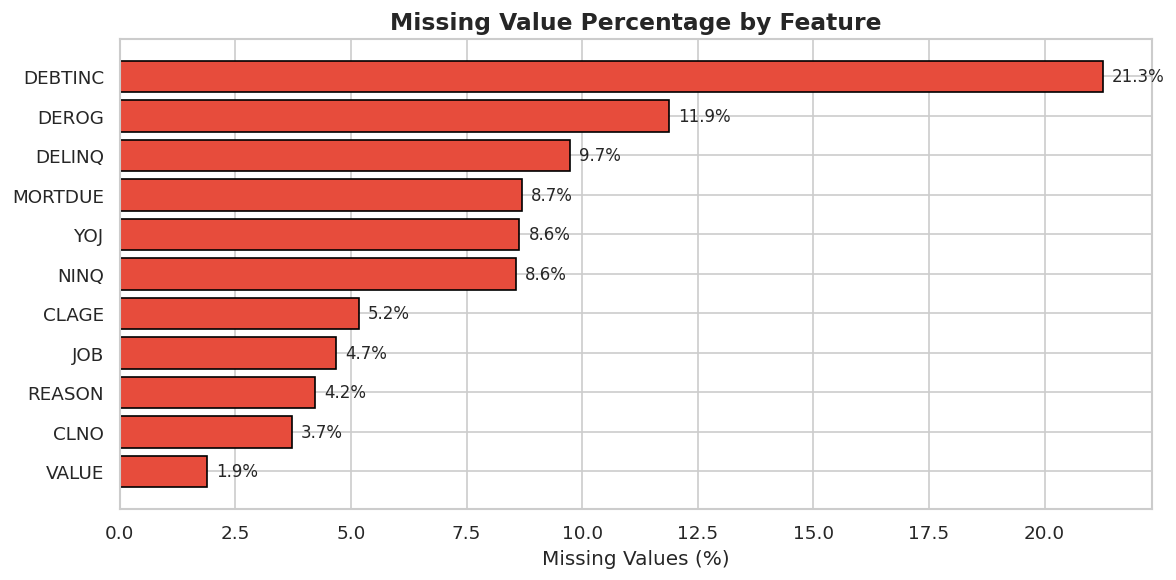

In [33]:
# Missing value analysis — detailed
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing = missing[missing['Missing Count'] > 0]
print(missing)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing.index, missing['Missing %'], color=COLOR_DEFAULT, edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Percentage by Feature', fontsize=14, fontweight='bold')
for i, v in enumerate(missing['Missing %']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
# Duplicate check
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


<a id="sec-eda"></a>

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the data's distribution, relationships, and patterns before modeling. We examine each feature individually (univariate), then in relation to the target variable and to one another (bivariate and multivariate).

<a id="sec-eda-uni"></a>

### 3.1 Univariate Analysis — Numerical Features
We inspect the distribution of each numerical feature. Histograms with a median reference line reveal central tendency, spread, and skew. Highly skewed features (e.g. `DEROG`, `DELINQ`) will need careful treatment before modeling.

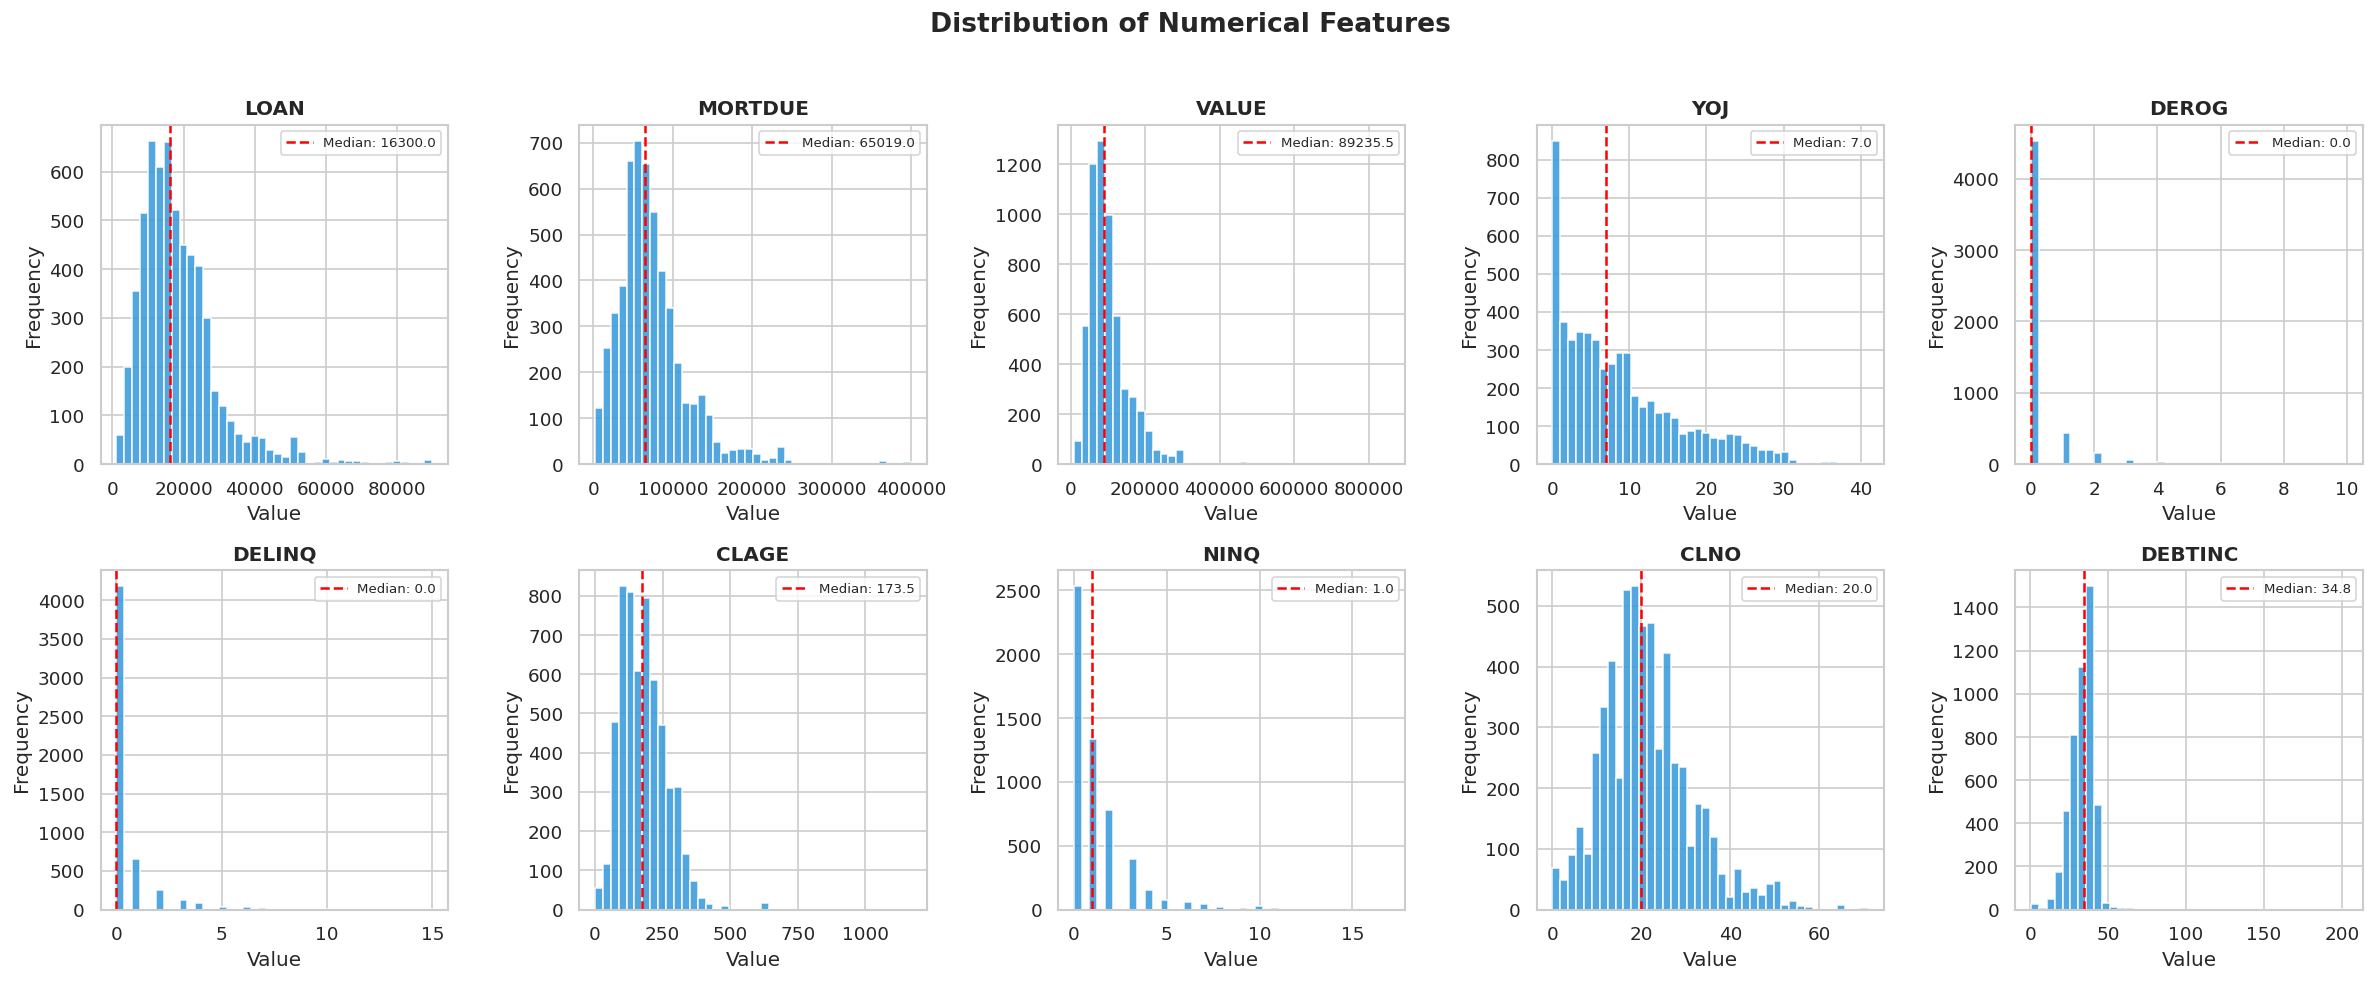

In [35]:
numerical_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ',
                  'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=40, color=COLOR_NEUTRAL, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=8)
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# Skewness table
skew_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Skewness': [df[col].skew() for col in numerical_cols]
}).sort_values('Skewness', ascending=False)
print("=== Skewness of Numerical Features ===")
print(skew_df.to_string(index=False))
print("\nNote: Skewness > 1 indicates high positive skew that may require transformation.")

=== Skewness of Numerical Features ===
Feature  Skewness
  DEROG  5.320870
 DELINQ  4.023150
  VALUE  3.053344
DEBTINC  2.852353
   NINQ  2.621984
   LOAN  2.023781
MORTDUE  1.814481
  CLAGE  1.343412
    YOJ  0.988460
   CLNO  0.775052

Note: Skewness > 1 indicates high positive skew that may require transformation.


<a id="sec-eda-target"></a>

### 3.2 Target Variable Analysis
Class distribution analysis is critical for imbalanced classification problems. If the target is highly imbalanced, a naive model can achieve high accuracy simply by always predicting the majority class while completely failing to detect defaulters.

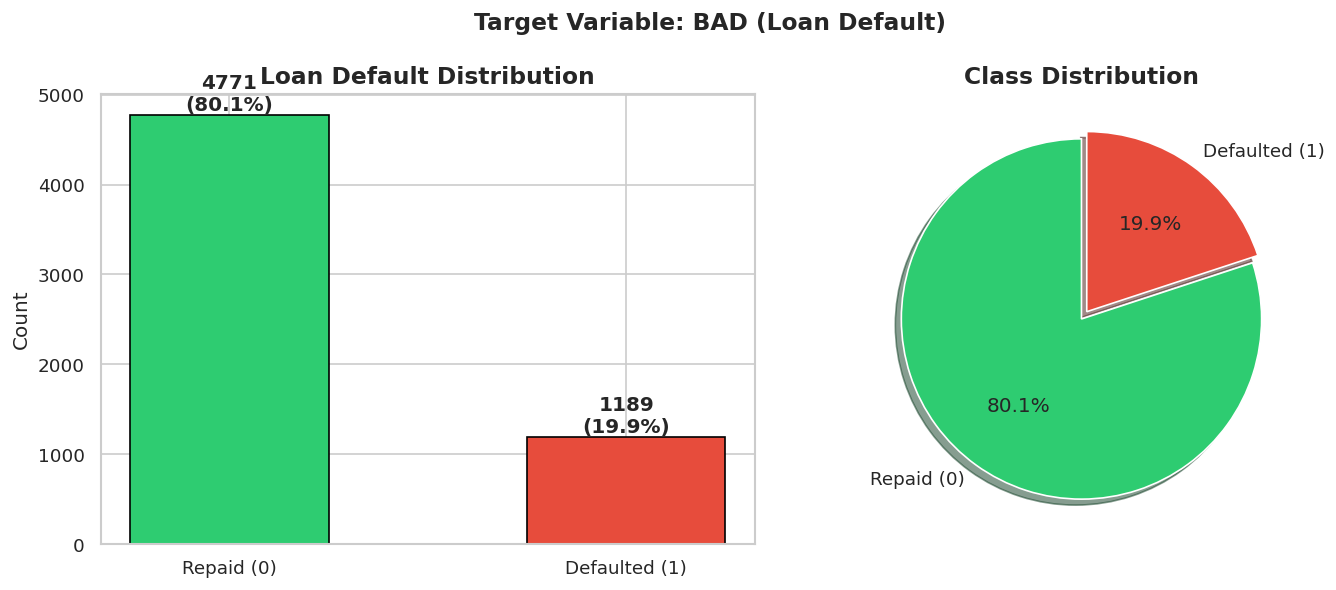


Class Distribution:
BAD
0    4771
1    1189
Name: count, dtype: int64

Class Imbalance Ratio: 80.1% Non-Default vs 19.9% Default
-> This imbalance must be handled before model training.


In [37]:
target_counts = df['BAD'].value_counts()
target_pct = df['BAD'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts,
            color=[COLOR_REPAID, COLOR_DEFAULT], edgecolor='black', width=0.5)
for i, (count, pct) in enumerate(zip(target_counts, target_pct)):
    axes[0].text(i, count + 50, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Loan Default Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(target_counts, labels=['Repaid (0)', 'Defaulted (1)'],
            colors=[COLOR_REPAID, COLOR_DEFAULT], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: BAD (Loan Default)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClass Distribution:\n{target_counts}\n")
print(f"Class Imbalance Ratio: {target_pct[0]:.1f}% Non-Default vs {target_pct[1]:.1f}% Default")
print("-> This imbalance must be handled before model training.")

<a id="sec-eda-bi"></a>

### 3.3 Bivariate Analysis
We now examine how each feature relates to the target variable `BAD`. This reveals which features are strong predictors of default. We start with the categorical features, then compare numerical distributions across default status, and finally confirm significance with a statistical test.

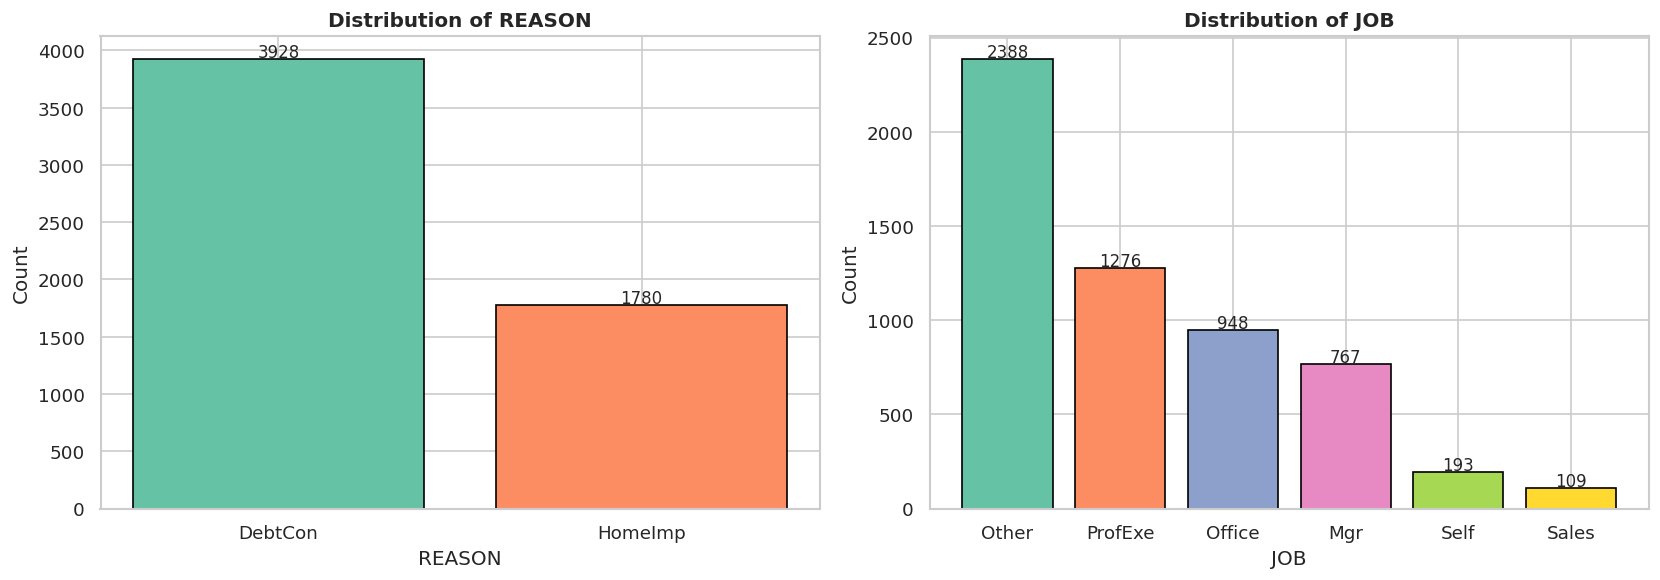

In [38]:
# Distribution of categorical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['REASON', 'JOB']):
    counts = df[col].value_counts()
    colors = sns.color_palette('Set2', len(counts))
    ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 10, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

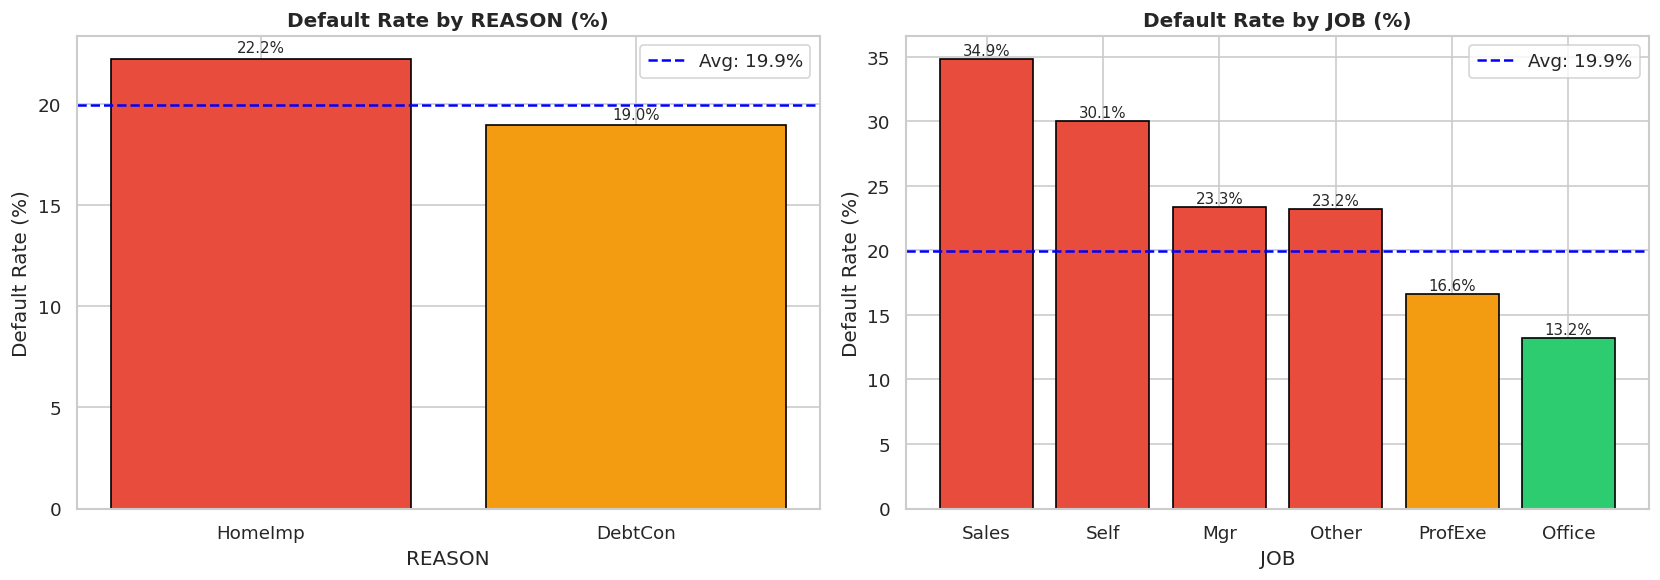

In [39]:
# Default rate by categorical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['REASON', 'JOB']):
    default_rate = df.groupby(col)['BAD'].mean().sort_values(ascending=False) * 100
    colors = ['#E74C3C' if v > 20 else '#F39C12' if v > 15 else '#2ECC71' for v in default_rate]
    ax.bar(default_rate.index, default_rate.values, color=colors, edgecolor='black')
    ax.set_title(f'Default Rate by {col} (%)', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Default Rate (%)')
    ax.axhline(df['BAD'].mean()*100, color='blue', linestyle='--',
               label=f'Avg: {df["BAD"].mean()*100:.1f}%')
    ax.legend()
    for j, v in enumerate(default_rate.values):
        ax.text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

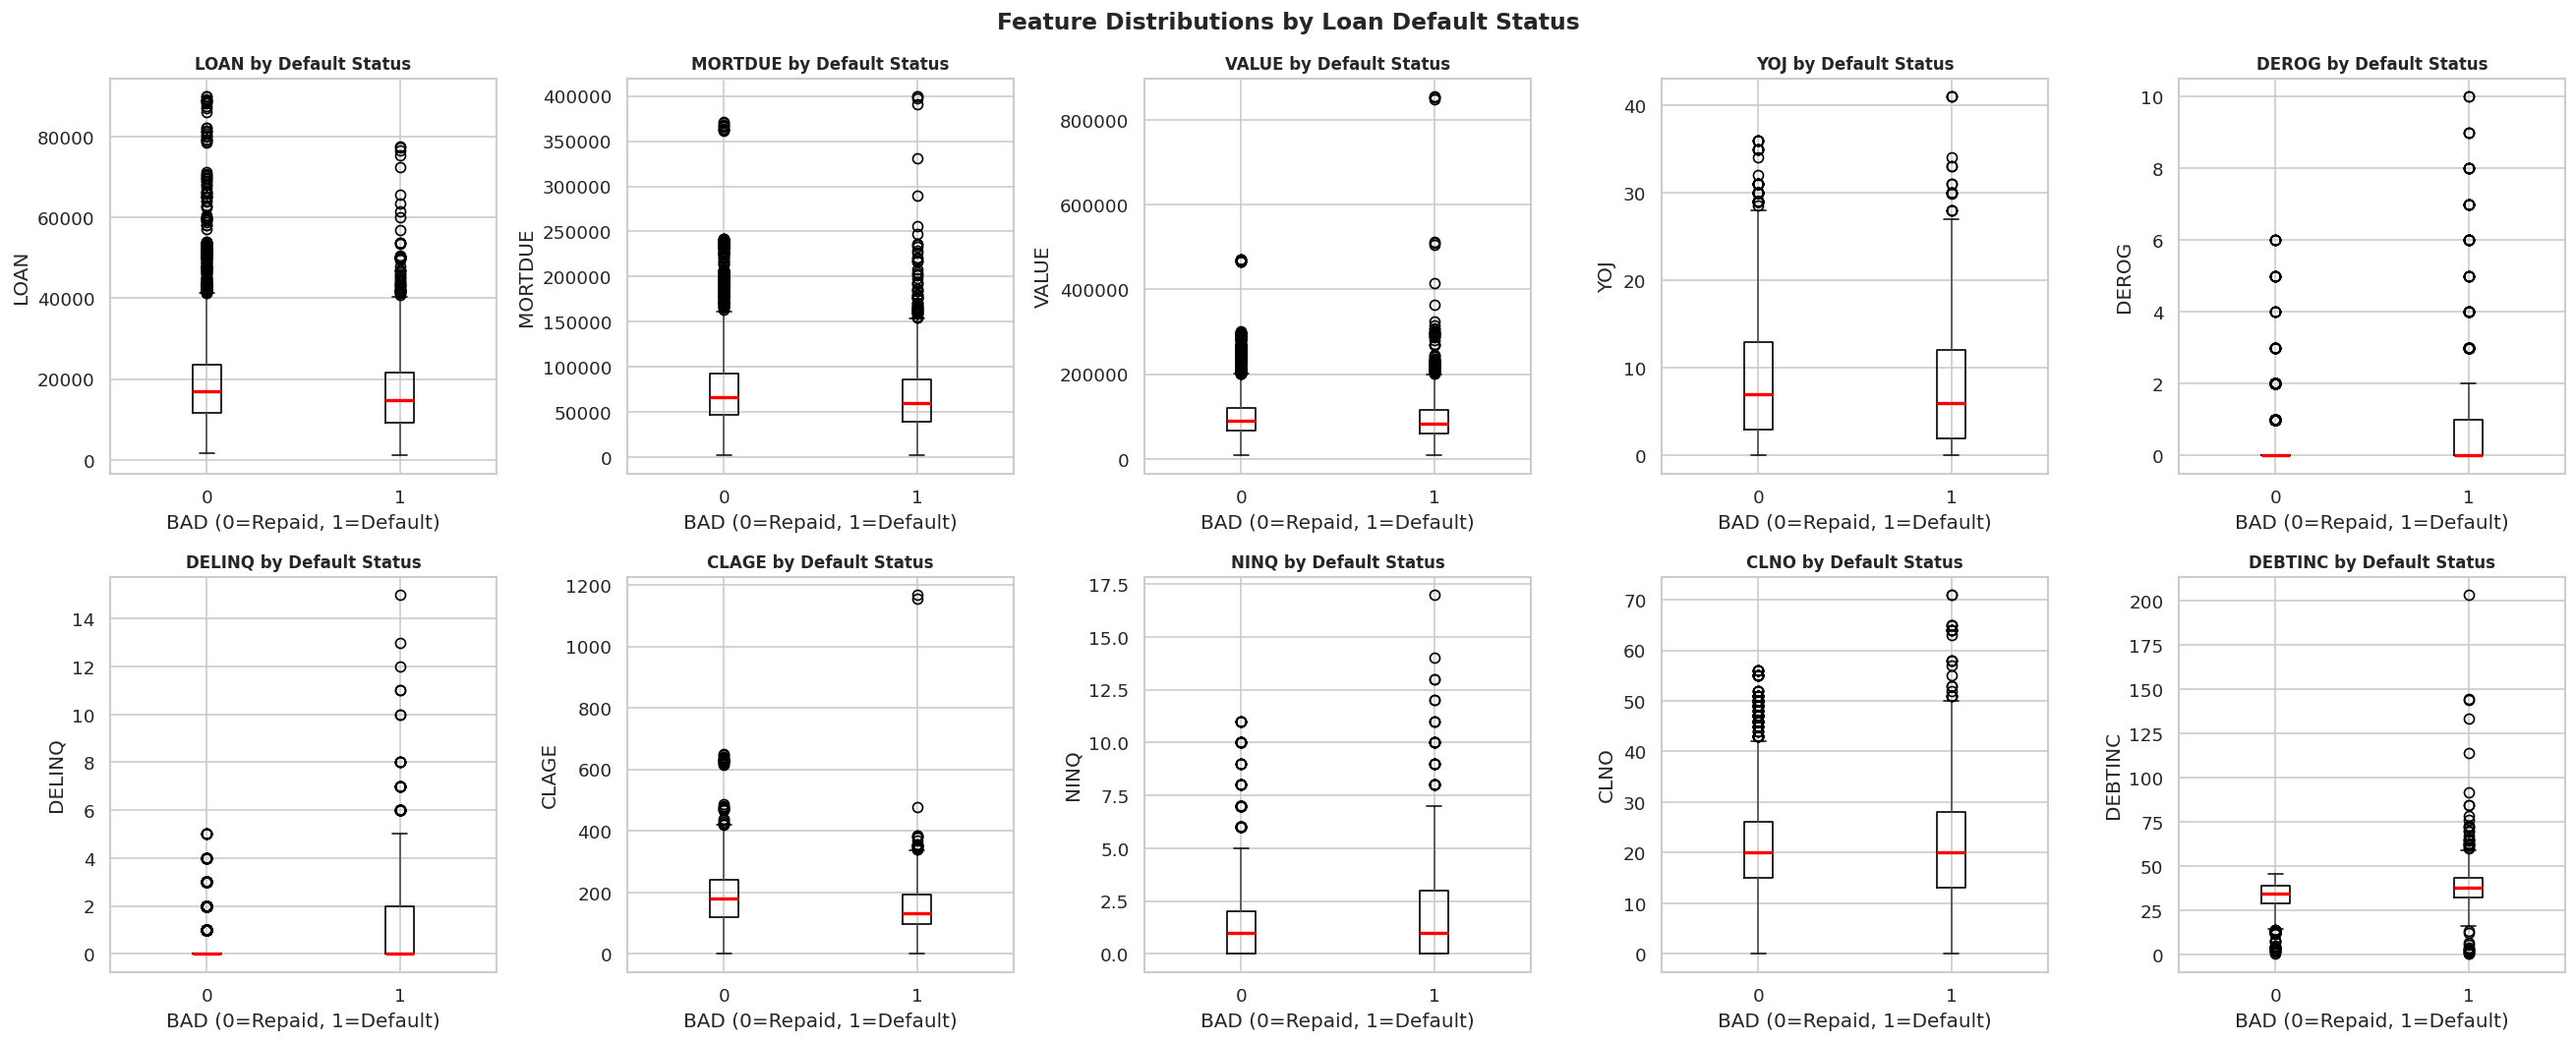

In [40]:
# Box plots: numerical features by default status
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='BAD', ax=axes[i],
               boxprops=dict(color='black'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Default Status', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('BAD (0=Repaid, 1=Default)')
    axes[i].set_ylabel(col)
plt.suptitle('Feature Distributions by Loan Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# Statistical test: are the differences between defaulters and non-defaulters significant?
print("=== Hypothesis Testing: Mann-Whitney U Test ===")
print("H0: No difference in distribution between defaulters and non-defaulters")
print("H1: Significant difference exists (p < 0.05 = significant)\n")
for col in numerical_cols:
    group0 = df[df['BAD'] == 0][col].dropna()
    group1 = df[df['BAD'] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    sig = 'SIGNIFICANT' if p < 0.05 else 'Not Significant'
    print(f"  {col:12s}: p-value = {p:.4f}  ->  {sig}")

=== Hypothesis Testing: Mann-Whitney U Test ===
H0: No difference in distribution between defaulters and non-defaulters
H1: Significant difference exists (p < 0.05 = significant)

  LOAN        : p-value = 0.0000  ->  SIGNIFICANT
  MORTDUE     : p-value = 0.0000  ->  SIGNIFICANT
  VALUE       : p-value = 0.0000  ->  SIGNIFICANT
  YOJ         : p-value = 0.0000  ->  SIGNIFICANT
  DEROG       : p-value = 0.0000  ->  SIGNIFICANT
  DELINQ      : p-value = 0.0000  ->  SIGNIFICANT
  CLAGE       : p-value = 0.0000  ->  SIGNIFICANT
  NINQ        : p-value = 0.0000  ->  SIGNIFICANT
  CLNO        : p-value = 0.2579  ->  Not Significant
  DEBTINC     : p-value = 0.0000  ->  SIGNIFICANT


<a id="sec-eda-multi"></a>

### 3.4 Multivariate Analysis
We examine the correlation structure among numerical features and the target, then zoom into the two strongest behavioural red flags — `DEROG` (derogatory reports) and `DELINQ` (delinquent credit lines) — to see how default rate climbs with each.

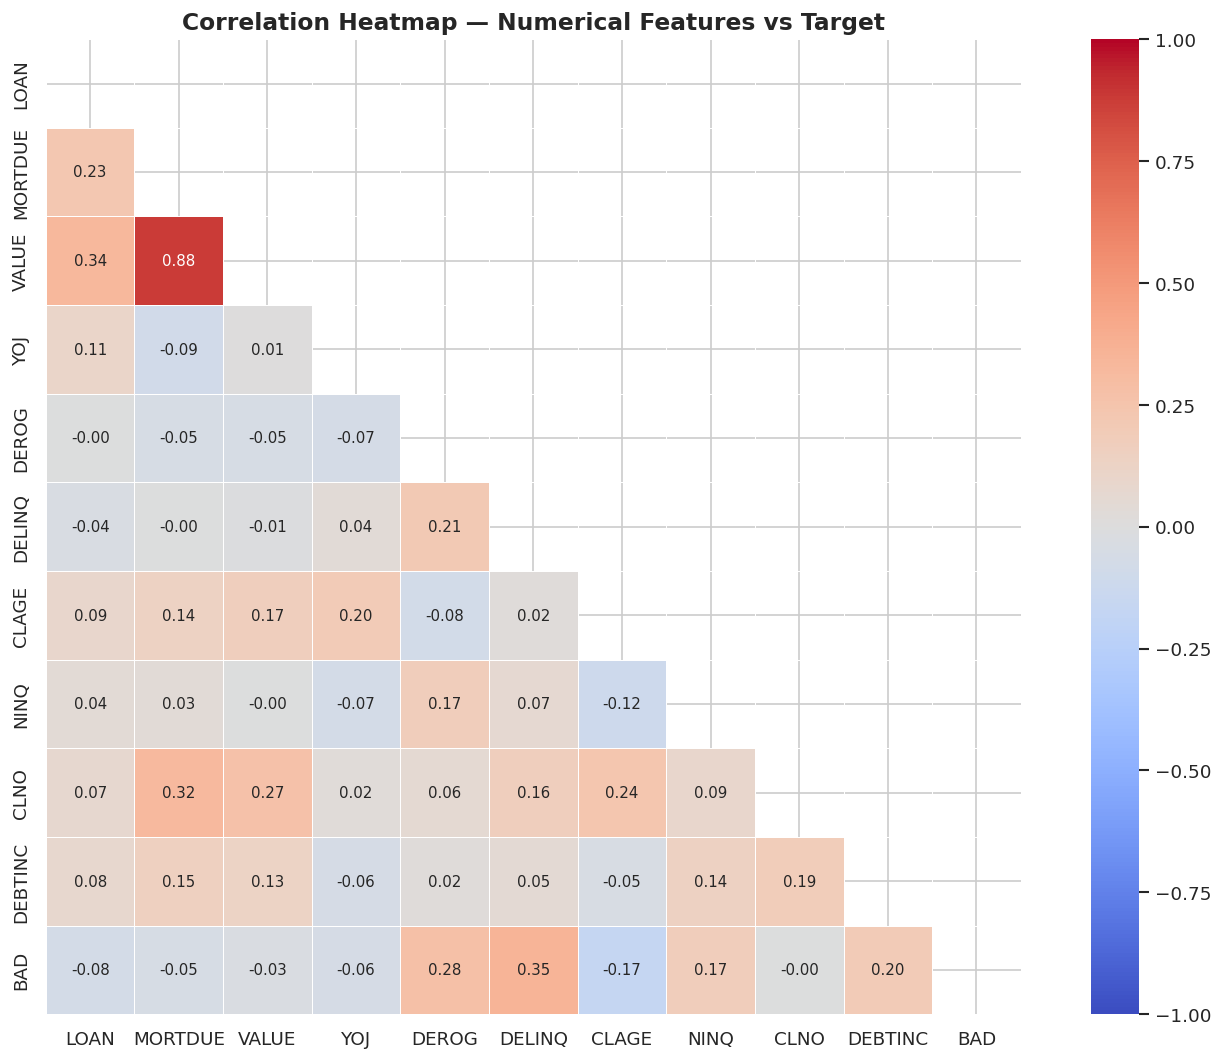

In [42]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df[numerical_cols + ['BAD']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

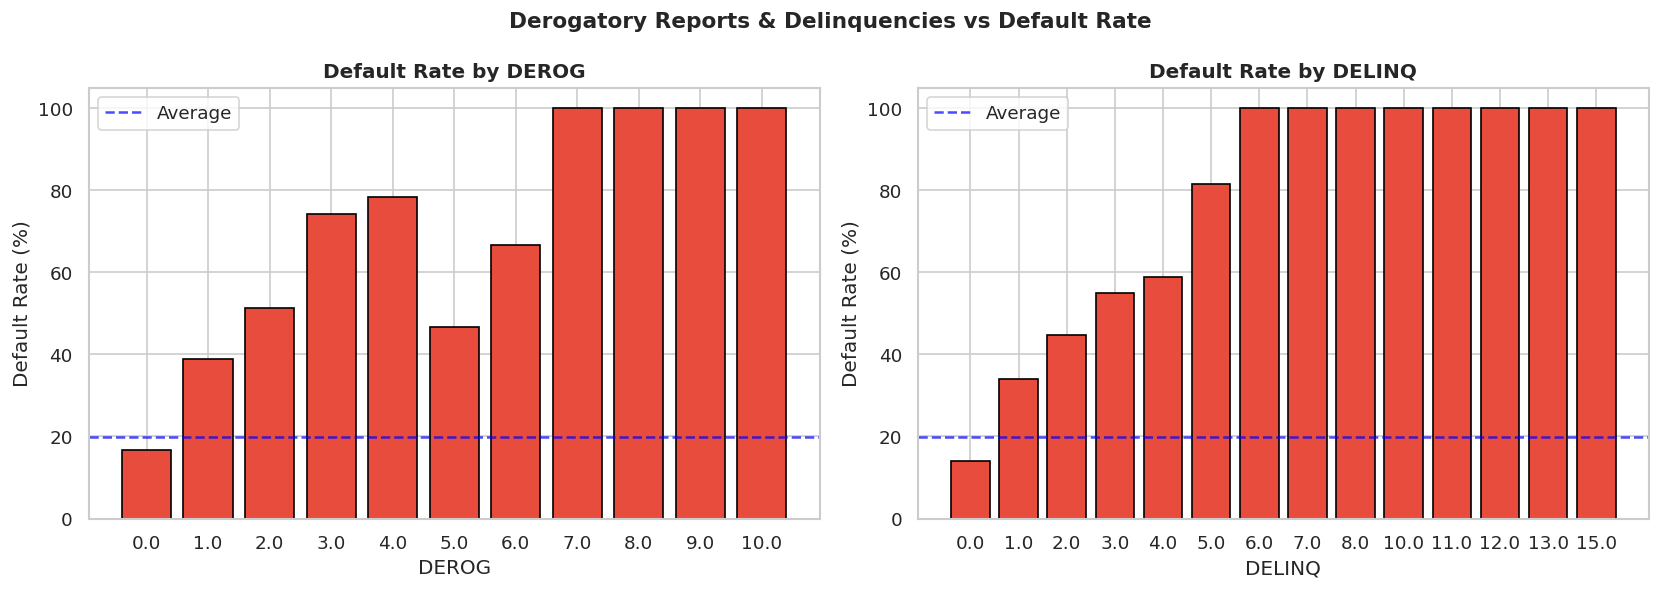

In [43]:
# Default rate across DEROG and DELINQ buckets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['DEROG', 'DELINQ']):
    rate = df.groupby(col)['BAD'].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color=COLOR_DEFAULT, edgecolor='black')
    ax.set_title(f'Default Rate by {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Default Rate (%)')
    ax.axhline(df['BAD'].mean()*100, color='blue', linestyle='--', alpha=0.7, label='Average')
    ax.legend()
plt.suptitle('Derogatory Reports & Delinquencies vs Default Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="sec-eda-insights"></a>

### 3.5 Key EDA Insights

1. **Class imbalance (~80/20):** Only ~20% of loans defaulted. Accuracy alone is misleading; we must optimize for **Recall on the default class**.
2. **`DEBTINC` has the most missing values (~21%).** Non-disclosure of debt-to-income may itself be informative, so we will flag it rather than silently impute.
3. **`DEROG` and `DELINQ` are the strongest red flags:** default rate rises sharply — often above 50%+ — as the number of derogatory reports or delinquent lines increases.
4. **Highly skewed features** (`DEROG` skew ≈ 5.3, `DELINQ` ≈ 4.0) are dominated by zeros with long tails; binary "has any" flags capture much of their signal.
5. **`DEBTINC` is positively associated with default** — higher debt-to-income ratios mean weaker capacity to repay.
6. **`CLAGE` is negatively associated with default** — longer credit history (older oldest credit line) signals a more established, lower-risk borrower.
7. **Loan purpose matters:** `DebtCon` vs `HomeImp` show different default rates, and `Sales`/`Self` occupations tend to carry higher risk than `Office`/`ProfExe`.
8. **`MORTDUE` and `VALUE` are strongly correlated** (both measure property/mortgage size) — a source of multicollinearity we address via engineered `EQUITY`.
9. **Extreme outliers exist** — `DEBTINC` reaches ~ 203% and `CLAGE` extends to ~ 1168 months (~97 years) — requiring outlier treatment.
10. **Mann-Whitney U tests confirm** that most numerical features differ significantly between defaulters and non-defaulters (p < 0.05), validating their predictive value.

<div style="border-left:5px solid #1a3c6b;background:#eef4fb;padding:10px 14px;margin-top:10px;border-radius:4px;"><b>💼 Business takeaway.</b> In plain terms, the applicants who default are those with <b>past credit trouble</b> (delinquencies, derogatory reports), a <b>high debt burden</b>, or a <b>thin credit history</b>. These signals are intuitive and defensible &mdash; the bank can explain a decline to a customer or a regulator without resorting to a black box.</div>

<div align="right"><a href="#top">↑ Back to top</a></div>

---

## 4. Rigorous Model Development and Final Validation

<a id="sec-analysis-design"></a>

### 4.1 Analysis Design and Leakage Controls

The earlier submission selected a probability threshold on the test set and evaluated performance on that same test set. That approach risks optimistic performance estimates. This final analysis corrects the issue:

1. A stratified split reserves 20% of observations as an untouched test set.
2. The remaining observations are split into 60% training and 20% validation samples.
3. Preprocessing and SMOTE are contained inside each cross-validation fold.
4. Random Forest and XGBoost hyperparameters are selected using cross-validated Average Precision on training data.
5. For each model, validation data select the **highest-precision threshold that achieves at least 85% recall**.
6. Validation performance selects the model. The locked model and threshold are then evaluated once on the test set.

Average Precision guides tuning because it summarises precision-recall performance under class imbalance. ROC-AUC, precision, recall, F1 and accuracy remain part of the assessment; no single metric is sufficient for a lending decision.


In [44]:
X = df.drop(columns='BAD')
y = df['BAD']
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)

split_summary = pd.DataFrame({
    'Sample': ['Training', 'Validation', 'Test'],
    'N': [len(X_train), len(X_val), len(X_test)],
    'Share': [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
    'Default rate': [y_train.mean(), y_val.mean(), y_test.mean()]
})
split_summary.style.format({'Share':'{:.1%}', 'Default rate':'{:.1%}'})

,Sample,N,Share,Default rate
0,Training,3576,60.0%,19.9%
1,Validation,1192,20.0%,20.0%
2,Test,1192,20.0%,20.0%


In [45]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preprocess = ColumnTransformer([
    ('num', SkPipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
    ]), num_cols),
    ('cat', SkPipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
models = {
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
        {'model__n_estimators':[200,300,400,500], 'model__max_depth':[None,6,10,14,20],
         'model__min_samples_split':[2,5,10,20], 'model__min_samples_leaf':[1,2,4,8],
         'model__max_features':['sqrt','log2',0.7]}),
    'XGBoost': (
        XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=SEED, n_jobs=-1),
        {'model__n_estimators':[200,300,400,500], 'model__max_depth':[3,4,5,6],
         'model__learning_rate':[0.03,0.05,0.08,0.1,0.15], 'model__subsample':[0.7,0.85,1.0],
         'model__colsample_bytree':[0.7,0.85,1.0], 'model__min_child_weight':[1,3,5],
         'model__reg_lambda':[1,3,5,10]})
}
print('Leakage-resistant pipelines defined: preprocessing → SMOTE → classifier.')

Leakage-resistant pipelines defined: preprocessing → SMOTE → classifier.


In [20]:
def choose_threshold(y_true, prob, target_recall=0.85):
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    eligible = [(p, r, t) for p, r, t in zip(precision[:-1], recall[:-1], thresholds)
                if r >= target_recall]
    return max(eligible, key=lambda z: (z[0], z[2]))

def metric_row(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {'Threshold':threshold, 'ROC-AUC':roc_auc_score(y_true, prob),
            'Average Precision':average_precision_score(y_true, prob),
            'Accuracy':accuracy_score(y_true, pred), 'Precision':precision_score(y_true, pred),
            'Recall':recall_score(y_true, pred), 'F1':f1_score(y_true, pred),
            'TN':tn, 'FP':fp, 'FN':fn, 'TP':tp}

searches, validation_results = {}, {}
for name, (model, params) in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('smote', SMOTE(random_state=SEED)), ('model', model)])
    search = RandomizedSearchCV(pipe, params, n_iter=20, scoring='average_precision',
                                cv=cv, random_state=SEED, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    prob = search.predict_proba(X_val)[:,1]
    precision, recall, threshold = choose_threshold(y_val, prob, target_recall=0.85)
    validation_results[name] = metric_row(y_val, prob, threshold)
    validation_results[name]['CV Average Precision'] = search.best_score_
    searches[name] = search
    print(f'{name}: threshold={threshold:.3f}, validation recall={recall:.3f}, precision={precision:.3f}')

validation_table = pd.DataFrame(validation_results).T
validation_table[['CV Average Precision','Threshold','ROC-AUC','Average Precision','Accuracy','Precision','Recall','F1']].style.format('{:.4f}')

Random Forest: threshold=0.408, validation recall=0.853, precision=0.744
XGBoost: threshold=0.239, validation recall=0.853, precision=0.757


,CV Average Precision,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1
Random Forest,0.8321,0.4080,0.9576,0.8384,0.9119,0.7436,0.8529,0.7945
XGBoost,0.8777,0.2394,0.9489,0.8819,0.9161,0.7575,0.8529,0.8024


In [21]:
# Model selection uses validation performance only.
selected_model = max(validation_results,
                     key=lambda n: (validation_results[n]['Precision'],
                                    validation_results[n]['Average Precision']))
locked_threshold = validation_results[selected_model]['Threshold']
selected_estimator = searches[selected_model].best_estimator_
print(f'Selected model: {selected_model}')
print(f'Locked threshold: {locked_threshold:.6f} (reported as {locked_threshold:.2f})')
print('Selection rule: highest validation precision subject to recall >= 0.85')
print('\nBest hyperparameters:')
for key, value in searches[selected_model].best_params_.items():
    print(f'  {key.replace("model__", "")}: {value}')

Selected model: XGBoost
Locked threshold: 0.239380 (reported as 0.24)
Selection rule: highest validation precision subject to recall >= 0.85

Best hyperparameters:
  subsample: 0.85
  reg_lambda: 5
  n_estimators: 500
  min_child_weight: 3
  max_depth: 6
  learning_rate: 0.08
  colsample_bytree: 0.85


<a id="sec-model-threshold-selection"></a>

### 4.2 Model and Threshold Selection

Cross-validation tunes both candidate pipelines. Validation data then select the model and the highest-precision threshold that maintains recall of at least 85%. These decisions are locked before the test outcomes are examined.

<a id="sec-test-evaluation"></a>

### 4.3 Untouched Test-Set Evaluation

The following cell is the first and only stage that uses test outcomes. The model and threshold are already locked. The analysis does not alter either choice after seeing these results.

In [22]:
test_rows = {}
test_probabilities = {}
for name, search in searches.items():
    prob = search.best_estimator_.predict_proba(X_test)[:,1]
    test_probabilities[name] = prob
    test_rows[name] = metric_row(y_test, prob, validation_results[name]['Threshold'])

test_table = pd.DataFrame(test_rows).T
display(test_table[['Threshold','ROC-AUC','Average Precision','Accuracy','Precision','Recall','F1','TN','FP','FN','TP']]
        .style.format({c:'{:.4f}' for c in ['Threshold','ROC-AUC','Average Precision','Accuracy','Precision','Recall','F1']}))

final = test_rows[selected_model]
print(f"FINAL LOCKED TEST RESULT — {selected_model} at threshold {locked_threshold:.3f}")
print(f"ROC-AUC {final['ROC-AUC']:.4f} | AP {final['Average Precision']:.4f} | "
      f"Recall {final['Recall']:.4f} | Precision {final['Precision']:.4f} | "
      f"F1 {final['F1']:.4f} | Accuracy {final['Accuracy']:.4f}")

,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
Random Forest,0.4080,0.9620,0.8581,0.9094,0.7519,0.8151,0.7823,890.000000,64.000000,44.000000,194.000000
XGBoost,0.2394,0.9540,0.8783,0.9102,0.7510,0.8235,0.7856,889.000000,65.000000,42.000000,196.000000


FINAL LOCKED TEST RESULT — XGBoost at threshold 0.239
ROC-AUC 0.9540 | AP 0.8783 | Recall 0.8235 | Precision 0.7510 | F1 0.7856 | Accuracy 0.9102


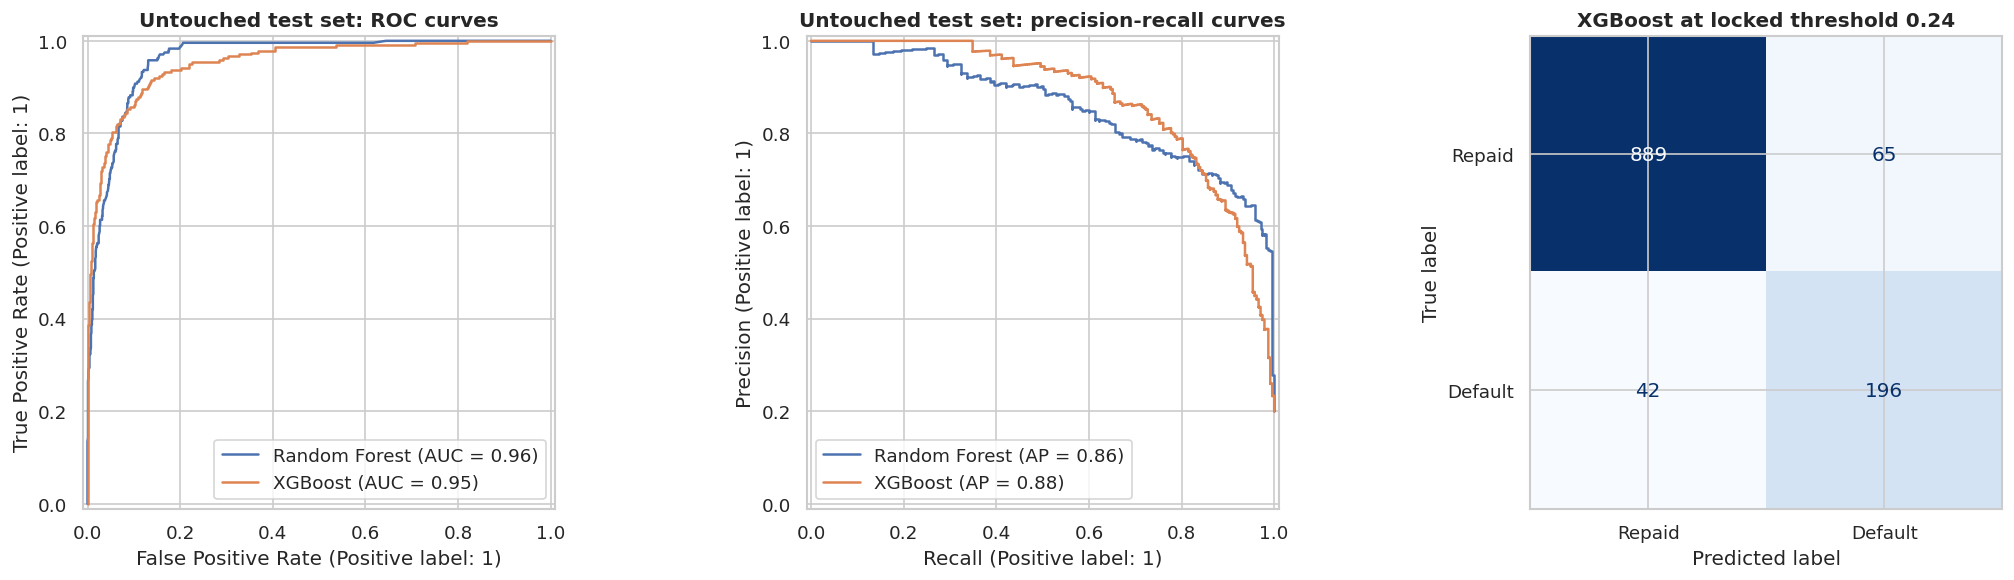

              precision    recall  f1-score   support

      Repaid       0.95      0.93      0.94       954
     Default       0.75      0.82      0.79       238

    accuracy                           0.91      1192
   macro avg       0.85      0.88      0.86      1192
weighted avg       0.91      0.91      0.91      1192



In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, prob in test_probabilities.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=axes[1])
axes[0].set_title('Untouched test set: ROC curves', fontweight='bold')
axes[1].set_title('Untouched test set: precision-recall curves', fontweight='bold')

pred = (test_probabilities[selected_model] >= locked_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Repaid','Default'],
                                        cmap='Blues', colorbar=False, ax=axes[2])
axes[2].set_title(f'{selected_model} at locked threshold {locked_threshold:.2f}', fontweight='bold')
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred, target_names=['Repaid','Default']))

### 4.4 Standard threshold versus the business operating threshold

The 0.50 cutoff produces higher precision but misses more defaulters. The validation-selected 0.239 threshold accepts more false alerts in exchange for materially higher default recall.

In [24]:
prob = test_probabilities[selected_model]
comparison = pd.DataFrame({
    'Standard threshold (0.50)': metric_row(y_test, prob, 0.50),
    f'Locked business threshold ({locked_threshold:.3f})': metric_row(y_test, prob, locked_threshold)
}).T
comparison[['Threshold','Accuracy','Precision','Recall','F1','TN','FP','FN','TP']].style.format(
    {c:'{:.4f}' for c in ['Threshold','Accuracy','Precision','Recall','F1']})

,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
Standard threshold (0.50),0.5000,0.9203,0.8629,0.7143,0.7816,927.000000,27.000000,68.000000,170.000000
Locked business threshold (0.239),0.2394,0.9102,0.7510,0.8235,0.7856,889.000000,65.000000,42.000000,196.000000


<a id="sec-business-recommendations"></a>

## 5. Interpretation and Business Recommendations

### Model decision

Tuned XGBoost remains the recommended model. On validation data, it achieved slightly higher precision than tuned Random Forest while both met the minimum 85% recall requirement. On the untouched test set, both models generalised similarly, while XGBoost retained a small F1 and recall advantage at their locked thresholds.

### Operating implications

- At threshold **0.239**, XGBoost correctly identified **196 of 238 defaulters** and missed 42.
- It incorrectly flagged 65 of 954 repayers, producing default-class precision of **0.7510**.
- At threshold 0.50, precision increases to 0.8629, but recall falls to 0.7143 and the model misses 68 defaulters.
- The lower threshold therefore better reflects the stated priority of avoiding costly false negatives.

### Deployment safeguards

The bank should validate the threshold using its actual loss-given-default and false-rejection costs before deployment. It should also assess probability calibration, subgroup fairness, temporal drift and stability on a more recent external sample. SHAP or other explanation methods can support adverse-action reasoning, but they do not independently establish legal compliance.

### Limitations

- The validation recall target does not guarantee the same recall on unseen data; test recall was 0.8235.
- HMEQ contains historical approved applicants and may not represent rejected applicants or current lending conditions.
- SMOTE creates synthetic minority observations and requires monitoring under distribution shift.
- This project does not include an externally supplied business cost matrix or independent temporal validation dataset.


<a id="sec-business-value"></a>

---

## 6. Illustrative Business Value 💵

### Monetary illustration for the selected model

The classification metrics show how well the model separates defaulters from repayers, but decision-makers also need to understand the possible financial scale. The following calculation translates the **locked test confusion matrix** into monetary terms using transparent hypothetical assumptions.

> **Important:** This is an illustrative decision model, not a forecast, valuation, savings guarantee or confirmed return on investment. The bank must replace every assumption with validated portfolio data before using the results for an investment or deployment decision.

The illustration assumes that applications with predicted probability ≥0.239 enter an enhanced review or risk-mitigation process. It does **not** assume automatic rejection. Potential value comes from preventing or reducing losses among correctly flagged defaulters. Costs include reviewing flagged applications, operating the model and the possibility that some repayers are incorrectly declined after review.

#### Calculation framework

For a portfolio of 1,000 applications:

\[
\text{Avoided default loss} = \text{expected true positives} \times \text{average exposure} \times \text{LGD} \times \text{intervention effectiveness}
\]

\[
\text{Review cost} = \text{expected flagged applications} \times \text{cost per enhanced review}
\]

\[
\text{False-decline opportunity cost} = \text{expected false positives} \times \text{false-decline probability} \times \text{lost margin}
\]

\[
\text{Illustrative net value} = \text{avoided default loss} - \text{review cost} - \text{false-decline cost} - \text{model operating cost}
\]

The observed test-set rates are used only to scale the example: 196 true positives, 65 false positives, 42 false negatives and 889 true negatives among 1,192 applications.


In [25]:
# Illustrative business-value model based on the locked test confusion matrix.
# Replace these assumptions with validated bank data before any real decision.

# Counts are pulled directly from the locked test evaluation (test_rows) so this
# illustration always tracks the selected model and its locked threshold, rather
# than relying on hard-coded numbers that could drift on a re-run.
_locked = test_rows[selected_model]
tp, fp, fn, tn = int(_locked['TP']), int(_locked['FP']), int(_locked['FN']), int(_locked['TN'])
test_n = tp + fp + fn + tn
portfolio_size = 1_000

# Convert observed test counts into expected counts per 1,000 applications.
expected_tp = tp / test_n * portfolio_size
expected_fp = fp / test_n * portfolio_size
expected_flagged = (tp + fp) / test_n * portfolio_size

# Three deliberately transparent sensitivity scenarios.
# "Conservative" combines lower loss avoidance with higher implementation costs.
scenarios = pd.DataFrame([
    {
        'Scenario': 'Conservative',
        'Average exposure ($)': 50_000,
        'Loss given default': 0.40,
        'Intervention effectiveness': 0.50,
        'Review cost per flagged case ($)': 250,
        'False-decline probability': 0.15,
        'Lost margin per false decline ($)': 5_000,
        'Model operating cost per application ($)': 50,
    },
    {
        'Scenario': 'Base illustration',
        'Average exposure ($)': 50_000,
        'Loss given default': 0.60,
        'Intervention effectiveness': 0.70,
        'Review cost per flagged case ($)': 150,
        'False-decline probability': 0.10,
        'Lost margin per false decline ($)': 3_000,
        'Model operating cost per application ($)': 25,
    },
    {
        'Scenario': 'Favourable',
        'Average exposure ($)': 50_000,
        'Loss given default': 0.75,
        'Intervention effectiveness': 0.85,
        'Review cost per flagged case ($)': 100,
        'False-decline probability': 0.05,
        'Lost margin per false decline ($)': 2_500,
        'Model operating cost per application ($)': 15,
    },
])

scenarios['Expected true positives / 1,000'] = expected_tp
scenarios['Expected false positives / 1,000'] = expected_fp
scenarios['Avoided default loss ($)'] = (
    expected_tp
    * scenarios['Average exposure ($)']
    * scenarios['Loss given default']
    * scenarios['Intervention effectiveness']
)
scenarios['Enhanced-review cost ($)'] = (
    expected_flagged * scenarios['Review cost per flagged case ($)']
)
scenarios['False-decline opportunity cost ($)'] = (
    expected_fp
    * scenarios['False-decline probability']
    * scenarios['Lost margin per false decline ($)']
)
scenarios['Model operating cost ($)'] = (
    portfolio_size * scenarios['Model operating cost per application ($)']
)
scenarios['Illustrative net value per 1,000 applications ($)'] = (
    scenarios['Avoided default loss ($)']
    - scenarios['Enhanced-review cost ($)']
    - scenarios['False-decline opportunity cost ($)']
    - scenarios['Model operating cost ($)']
)

value_columns = [
    'Scenario',
    'Avoided default loss ($)',
    'Enhanced-review cost ($)',
    'False-decline opportunity cost ($)',
    'Model operating cost ($)',
    'Illustrative net value per 1,000 applications ($)',
]

display(
    scenarios[value_columns].style
    .format({col: '${:,.0f}' for col in value_columns[1:]})
    .set_caption('Illustrative sensitivity analysis — not a forecast or confirmed ROI')
)

base_value = scenarios.loc[
    scenarios['Scenario'].eq('Base illustration'),
    'Illustrative net value per 1,000 applications ($)'
].iloc[0]

print(f'Expected flagged applications per 1,000: {expected_flagged:.1f}')
print(f'Expected correctly flagged defaulters per 1,000: {expected_tp:.1f}')
print(f'Base illustrative net value per 1,000 applications: ${base_value:,.0f}')
print('Interpretation: magnitude under stated assumptions only; replace assumptions with bank data.')

,Scenario,Avoided default loss ($),Enhanced-review cost ($),False-decline opportunity cost ($),Model operating cost ($),"Illustrative net value per 1,000 applications ($)"
0,Conservative,"$1,644,295","$54,740","$40,898","$50,000","$1,498,658"
1,Base illustration,"$3,453,020","$32,844","$16,359","$25,000","$3,378,817"
2,Favourable,"$5,241,191","$21,896","$6,816","$15,000","$5,197,479"


Expected flagged applications per 1,000: 219.0
Expected correctly flagged defaulters per 1,000: 164.4
Base illustrative net value per 1,000 applications: $3,378,817
Interpretation: magnitude under stated assumptions only; replace assumptions with bank data.


#### Interpretation

Under the assumptions above, the illustrative net value is approximately:

- **$1.50 million per 1,000 applications** in the conservative scenario;
- **$3.38 million per 1,000 applications** in the base illustration; and
- **$5.20 million per 1,000 applications** in the favourable scenario.

These values are driven primarily by assumed exposure, loss given default and the effectiveness of the action taken after a high-risk prediction. They should therefore be interpreted as a **sensitivity range showing possible scale**, not as evidence that the model will generate these savings.

The illustration excludes several factors that could materially change the result, including implementation expenditure, integration costs, recoveries after default, loan pricing, approval-rate changes, customer lifetime value, model deterioration, regulatory costs and behavioural responses. A proper business case would estimate these inputs from bank records, apply probability calibration, evaluate outcomes over time and compare the model-supported workflow with the bank's current underwriting process.


<a id="sec-final-conclusion"></a>

## 7. Final Conclusion

The corrected evaluation strengthens rather than reverses the conclusion. **Tuned XGBoost remains the preferred model**, but the evidence now supports a locked operating threshold of approximately **0.24**, rather than the earlier test-optimised values of 0.17 or 0.22. On the untouched test set, the final rule achieved ROC-AUC 0.9540, Average Precision 0.8783, recall 0.8235, precision 0.7510, F1 0.7856 and accuracy 0.9102.

The threshold should be treated as a candidate operating point. Final deployment requires validation against the bank's monetary cost matrix, risk appetite, fairness requirements and current applicant population.


<a id="sec-references"></a>

---
## References

1. **Breiman, L. (2001).** Random Forests. *Machine Learning*, 45(1), 5–32. [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)
   *(Foundational paper for the Random Forest algorithm, one of the ensemble models compared.)*

2. **Chen, T., & Guestrin, C. (2016).** XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794. [https://doi.org/10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)
   *(The gradient-boosting algorithm selected as the final model.)*

3. **Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002).** SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321–357. [https://doi.org/10.1613/jair.953](https://doi.org/10.1613/jair.953)
   *(Original SMOTE paper — the class-imbalance technique applied in this project.)*

4. **Lundberg, S. M., & Lee, S.-I. (2017).** A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems*, 30 (NeurIPS 2017). [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)
   *(Introduces SHAP values, used here for feature-importance and adverse-action explanations.)*

5. **Pedregosa, F., et al. (2011).** Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. [https://jmlr.org/papers/v12/pedregosa11a.html](https://jmlr.org/papers/v12/pedregosa11a.html)
   *(Primary ML library used throughout the project: preprocessing, models, evaluation, hyperparameter tuning.)*

6. **Hand, D. J., & Henley, W. E. (1997).** Statistical Classification Methods in Consumer Credit Scoring: A Review. *Journal of the Royal Statistical Society: Series A*, 160(3), 523–541. [https://doi.org/10.1111/j.1467-985X.1997.00078.x](https://doi.org/10.1111/j.1467-985X.1997.00078.x)
   *(Seminal review of credit scoring methodology and the context for applying machine learning to loan default prediction.)*

---
<div align="right"><a href="#top">↑ Back to top</a></div>


In [26]:
!jupyter nbconvert --to html '/content/drive/MyDrive/MIT_AAIDSP_2026/Capstone Project/Capstone_Project_Loan_Default_Prediction_Full_Code_Final_submission_10_Sept2026.ipynb'
from google.colab import files
files.download ('/content/drive/MyDrive/MIT_AAIDSP_2026/Capstone Project/Capstone_Project_Loan_Default_Prediction_Full_Code_Final_submission_10_Sept2026.html')

[NbConvertApp] Converting notebook /content/drive/MyDrive/MIT_AAIDSP_2026/Capstone Project/Capstone_Project_Loan_Default_Prediction_Full_Code_Final_submission_10_Sept2026.ipynb to html
[NbConvertApp] Writing 448919 bytes to /content/drive/MyDrive/MIT_AAIDSP_2026/Capstone Project/Capstone_Project_Loan_Default_Prediction_Full_Code_Final_submission_10_Sept2026.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>